# Bag of n_grams: Exercise
* Fake news refers to misinformation or disinformation in the country which is spread through word of mouth and more recently through digital communication such as What's app messages, social media posts, etc.
* Fake news spreads faster than Real news and creates problems and fear among groups and in society.
* We are going to address these problems using classical NLP techniques and going to classify whether a given message/ text is Real or Fake Message.
* You will use a Bag of n-grams to pre-process the text and apply different classification algorithms.

# About Data: Fake News Detection

Credits: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

This data consists of two columns. - Text - label

Text is the statements or messages regarding a particular event/situation.

label feature tells whether the given Text is Fake or Real.

As there are only 2 classes, this problem comes under the Binary Classification.

In [3]:
#import pandas library
import pandas as pd

#read the dataset with name "Fake_Real_Data.csv" and store it in a variable df
df = pd.read_csv('Fake_Real_Data.csv')

#print the shape of dataframe
print(df.shape)

#print top 5 rows
print(df.head())

(9900, 2)
                                                Text label
0   Top Trump Surrogate BRUTALLY Stabs Him In The...  Fake
1  U.S. conservative leader optimistic of common ...  Real
2  Trump proposes U.S. tax overhaul, stirs concer...  Real
3   Court Forces Ohio To Allow Millions Of Illega...  Fake
4  Democrats say Trump agrees to work on immigrat...  Real


In [4]:
#check the distribution of labels 
print(df.label.value_counts())

label
Fake    5000
Real    4900
Name: count, dtype: int64


* We can see that the Labels are more over Balanced already

In [5]:
#Add the new column "label_num" which gives a unique number to each of these labels 
df['label_num'] = df['label'].map({
    'Real':0,
    'Fake':1
})

#check the results with top 5 rows
print(df.head())

                                                Text label  label_num
0   Top Trump Surrogate BRUTALLY Stabs Him In The...  Fake          1
1  U.S. conservative leader optimistic of common ...  Real          0
2  Trump proposes U.S. tax overhaul, stirs concer...  Real          0
3   Court Forces Ohio To Allow Millions Of Illega...  Fake          1
4  Democrats say Trump agrees to work on immigrat...  Real          0


# Modelling without Pre-processing Text data

In [6]:
#import train-test-split from sklearn 
from sklearn.model_selection import train_test_split

#Do the 'train-test' splitting with test size of 20% with random state of 2022 and stratify sampling too
X_train,X_test,y_train,y_test = train_test_split(
    df.Text,
    df.label_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.label_num
)


In [7]:
#print the shapes of X_train and X_test
print("Shape of X_train and y_train with the distribution of y_train")
print(X_train.shape)
print(y_train.shape)
print(y_train.value_counts())


print("Shape of X_test and y_test with the distribution of y_test")
print(X_test.shape)
print(y_test.shape)
print(y_test.value_counts())


Shape of X_train and y_train with the distribution of y_train
(7920,)
(7920,)
label_num
1    4000
0    3920
Name: count, dtype: int64
Shape of X_test and y_test with the distribution of y_test
(1980,)
(1980,)
label_num
1    1000
0     980
Name: count, dtype: int64


Attempt 1 :
* Using sklearn pipeline module create a classification pipeline to classify the Data.

Note:
* using CountVectorizer with unigram, bigram, and trigrams.
* use KNN as the classifier with n_neighbors of 10 and metric as 'euclidean' distance.
* print the classification report.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Now creating the pipeline
clf = Pipeline([
    ('vectorizer',CountVectorizer()), # Unigram CountVector (Bag of 1 gram)
    ('knn',KNeighborsClassifier(n_neighbors=10,metric='euclidean'))
])

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))



              precision    recall  f1-score   support

           0       0.89      0.98      0.93       980
           1       0.98      0.88      0.93      1000

    accuracy                           0.93      1980
   macro avg       0.93      0.93      0.93      1980
weighted avg       0.93      0.93      0.93      1980



In [ ]:
clf = Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(2,2))), # Bigram CountVector (Bag of 2 gram)
    ('knn',KNeighborsClassifier(n_neighbors=10,metric='euclidean'))
])
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))


In [ ]:
clf = Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(3,3))), # Trigram CountVector (Bag of 3 gram)
    ('knn',KNeighborsClassifier(n_neighbors=10,metric='euclidean'))
])
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

clf = Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(1,3))), # Unigram + Bigram + Trigram CountVector
    ('knn',KNeighborsClassifier(n_neighbors=10,metric='euclidean'))
])
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.63      0.99      0.77       980
           1       0.98      0.42      0.59      1000

    accuracy                           0.70      1980
   macro avg       0.80      0.71      0.68      1980
weighted avg       0.80      0.70      0.68      1980



Attempt 2 :
* Using the sklearn pipeline module create a classification pipeline to classify the Data.
Note:

* using CountVectorizer with unigram, bigram, and trigrams.
* use KNN as the classifier with n_neighbors of 10 and metric as 'cosine' distance.
* print the classification report.

In [12]:
clf= Pipeline([
    ('vectorizer',CountVectorizer()),
    ('knn',KNeighborsClassifier(n_neighbors=10,metric='cosine'))
])
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90       980
           1       1.00      0.78      0.88      1000

    accuracy                           0.89      1980
   macro avg       0.91      0.89      0.89      1980
weighted avg       0.91      0.89      0.89      1980



In [13]:
clf= Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(2,2))),
    ('knn',KNeighborsClassifier(n_neighbors=10,metric='cosine'))
])
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      1.00      0.87       980
           1       0.99      0.71      0.83      1000

    accuracy                           0.85      1980
   macro avg       0.88      0.85      0.85      1980
weighted avg       0.88      0.85      0.85      1980



In [14]:
clf= Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(3,3))),
    ('knn',KNeighborsClassifier(n_neighbors=10,metric='cosine'))
])
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.99      0.90       980
           1       0.99      0.79      0.88      1000

    accuracy                           0.89      1980
   macro avg       0.91      0.89      0.89      1980
weighted avg       0.91      0.89      0.89      1980



In [15]:
clf= Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(1,3))),
    ('knn',KNeighborsClassifier(n_neighbors=10,metric='cosine'))
])
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.65      1.00      0.79       980
           1       1.00      0.47      0.64      1000

    accuracy                           0.73      1980
   macro avg       0.83      0.74      0.72      1980
weighted avg       0.83      0.73      0.71      1980



Attempt 3 :
* using the sklearn pipeline module create a classification pipeline to classify the Data.

Note:

* using CountVectorizer with only trigrams.
* use RandomForest as the classifier.
* print the classification report.

In [16]:
from sklearn.ensemble import RandomForestClassifier

clf= Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(3,3))),  # Why random forest with Trigram gives a great accuracy
    ('randomForest',RandomForestClassifier())
])
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       1.00      0.98      0.99      1000

    accuracy                           0.99      1980
   macro avg       0.99      0.99      0.99      1980
weighted avg       0.99      0.99      0.99      1980



Attempt 4 :
* using the sklearn pipeline module create a classification pipeline to classify the Data.

Note:

* using CountVectorizer with both unigram and bigrams.
* use Multinomial Naive Bayes as the classifier with an alpha value of 0.75.
* print the classification report.

In [17]:
# Trying the same thing with Naive Bayes -> MulitnomialNB
from sklearn.naive_bayes import MultinomialNB

clf= Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(1,1))),
    ('nb',MultinomialNB(alpha=0.75)) # why do we use alpha value? 
])
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       980
           1       0.97      0.97      0.97      1000

    accuracy                           0.97      1980
   macro avg       0.97      0.97      0.97      1980
weighted avg       0.97      0.97      0.97      1980



In [18]:

clf= Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(2,2))), # With taking less time than Randomforest Trigram, It gives us the same result as that.
    ('nb',MultinomialNB(alpha=0.75))
])
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.98      0.99      1000

    accuracy                           0.99      1980
   macro avg       0.99      0.99      0.99      1980
weighted avg       0.99      0.99      0.99      1980



# Use text pre-processing to remove stop words, punctuations and apply lemmatization

In [19]:
import spacy 
nlp = spacy.load("en_core_web_sm")

def preprocess(text): # This will remove the stop words and punctuations and then convert words in Base Words (using Lemmatization)
    doc= nlp(text)
    processed_text = [token.lemma_ for token in doc if not token.is_stop or not token.is_punct]
    return " ".join(processed_text)

In [20]:
# create a new column "preprocessed_txt" and use the utility function above to get the clean data
# this will take some time, please be patient

df['preprocessed_text'] = df.Text.apply(preprocess)

df.head()

,Text,label,label_num,preprocessed_text
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,1,Top Trump surrogate BRUTALLY Stabs he in the...
1,U.S. conservative leader optimistic of common ...,Real,0,U.S. conservative leader optimistic of common ...
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,0,"trump propose U.S. tax overhaul , stir concern..."
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,1,Court Forces Ohio to allow Millions of illeg...
4,Democrats say Trump agrees to work on immigrat...,Real,0,Democrats say Trump agree to work on immigrati...


# Build a model with pre processed text

In [54]:
#Do the 'train-test' splitting with test size of 20% with random state of 2022 and stratify sampling too
#Note: Make sure to use only the "preprocessed_txt" column for splitting

X_train,X_test,y_train,y_test = train_test_split(
    df.preprocessed_text,
    df.label_num,
    test_size=0.2,
    random_state= 2022,
    stratify= df.label_num
)

print(y_train.value_counts())

label_num
1    4000
0    3920
Name: count, dtype: int64


# Let's check the scores with our best model till now
* MultinomialNB + Bigram BoW
* RandomForest + Trigram

In [68]:
# from sklearn.feature_extraction.text import CountVectorizer
# from sklearn.model_selection import train_test_split
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report
# from sklearn.pipeline import Pipeline

# Random forest + Trigram
clf = Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(1,3))),
    ('randomForest',RandomForestClassifier())
])

clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1000

    accuracy                           1.00      1980
   macro avg       1.00      1.00      1.00      1980
weighted avg       1.00      1.00      1.00      1980



In [72]:
# Multinomial + Bigram
clf = Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(2,2))),
    ('nb',MultinomialNB(alpha=0.75))
])

clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.98      0.99      1000

    accuracy                           0.99      1980
   macro avg       0.99      0.99      0.99      1980
weighted avg       0.99      0.99      0.99      1980



In [73]:
#finally print the confusion matrix for the best model
from sklearn.metrics import confusion_matrix

cm= confusion_matrix(y_test,y_pred)
print(cm)

[[975   5]
 [ 23 977]]


Text(33.33333333333333, 0.5, 'Truth')

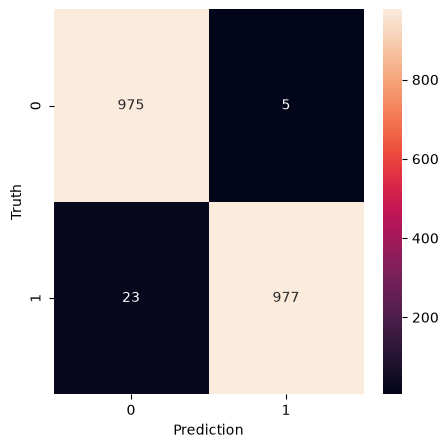

In [74]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,5))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Prediction")
plt.ylabel("Truth")


## Final Observation

In this exercise, different machine learning models were tested with different n-gram combinations for fake news classification.

- **KNN with Euclidean distance** performed less effectively because text data contains many features, and Euclidean distance is not always suitable for comparing text documents.
- **KNN with Cosine distance** generally performed better because cosine distance compares the similarity of text based on its direction rather than its size.
- **Random Forest with trigrams** performed well because trigrams capture short phrases and word combinations that can be useful for identifying writing patterns in fake and real news.
- **Multinomial Naive Bayes with bigrams** gave one of the best results. Bigrams preserve useful word combinations such as `"breaking news"` or `"fake claim"` while still keeping the model simple and fast.
- Using **unigrams, bigrams, and trigrams together** provides more information, but it also creates many features. This can increase memory usage and may not always improve the result.
- Text preprocessing removed stop words and punctuation and converted words to their base forms using lemmatization. This reduced unnecessary variations in the text and helped the models focus on meaningful words.

Overall, the **Multinomial Naive Bayes model with bigram features** is a good choice for this problem because it provides a strong result, trains quickly, and is suitable for word-count-based text classification. Random Forest with trigram features is also a useful alternative.

The confusion matrix helps us understand how many real and fake news articles were classified correctly and incorrectly. However, model performance should be judged using more than accuracy alone, including precision, recall, and F1-score. The final model should be selected based on the evaluation scores and the practical importance of correctly identifying fake news.